In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# DATA UNDERSTANDING

In [ ]:
FILE_PATH = 'data-indeks-standar-pencemar-udara-ispu-di-provinsi-dki-jakarta-2023.csv'

print(f"[INFO] Memuat dataset riil dari {FILE_PATH}...")
try:
    df_raw = pd.read_csv(FILE_PATH)
    print("[SUKSES] Dataset berhasil dimuat!")
except FileNotFoundError:
    print(f"[ERROR] File '{FILE_PATH}' tidak ditemukan.")
    print("MOHON PASTIKAN nama file di bawah ini sesuai dengan file yang Anda upload ke Colab.")
    import os
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
    if csv_files:
        FILE_PATH = csv_files[0]
        df_raw = pd.read_csv(FILE_PATH)
        print(f"[SUKSES] Otomatis beralih menggunakan file yang tersedia: '{FILE_PATH}'")
    else:
        raise FileNotFoundError("Silakan upload file CSV ISPU DKI 2023 terlebih dahulu ke folder Google Colab.")

df_raw.columns = df_raw.columns.str.lower()

print("\n--- Struktur Kolom Dataset Asli ---")
print(df_raw.info())
print("\n--- Tampilan 5 Data Teratas ---")
print(df_raw.head())

[INFO] Memuat dataset riil dari data-indeks-standar-pencemar-udara-ispu-di-provinsi-dki-jakarta-2023.csv...
[ERROR] File 'data-indeks-standar-pencemar-udara-ispu-di-provinsi-dki-jakarta-2023.csv' tidak ditemukan.
MOHON PASTIKAN nama file di bawah ini sesuai dengan file yang Anda upload ke Colab.
[SUKSES] Otomatis beralih menggunakan file yang tersedia: 'data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-2023-komponen-data.csv'

--- Struktur Kolom Dataset Asli ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   periode_data               1825 non-null   int64 
 1   tanggal                    1825 non-null   object
 2   stasiun                    1825 non-null   object
 3   pm_sepuluh                 1825 non-null   object
 4   pm_duakomalima             1825 non-null   object
 5   sulfur_dioksida     

In [ ]:
df_raw.head()

,tanggal,pm10,pm25,so2,co,o3,no2,kategori
0,2023-01-01,71,80,39,34,16,39,Tidak Sehat
1,2023-01-02,34,115,24,34,69,27,Tidak Sehat
2,2023-01-03,80,86,36,33,49,40,Tidak Sehat
3,2023-01-04,40,58,43,21,56,41,Sehat
4,2023-01-05,43,107,47,17,48,20,Tidak Sehat


# PREPROCESSING

In [ ]:
print("\n[INFO] Menjalankan proses Preprocessing & Pembersihan Data...")

df_clean = df_raw.copy()
features_numerik = ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida']

for col in features_numerik:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.replace('TIDAK ADA DATA', 'NaN')
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# ── Cek distribusi nilai kosong sebelum penanganan ──────────────────────────
print("\n--- Jumlah Nilai Kosong per Fitur (Sebelum Imputasi) ---")
print(df_clean[features_numerik].isnull().sum())

# ── Imputasi median untuk SEMUA fitur numerik (sebelum labeling) ─────────────
# Ini menyelamatkan baris yang hanya kosong di fitur minor (SO2, CO, O3, NO2),
# sehingga hanya baris yang benar-benar tidak punya PM2.5 DAN PM10 yang dibuang
for col in features_numerik:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

print("\n--- Nilai Kosong Setelah Imputasi Median ---")
print(df_clean[features_numerik].isnull().sum())

def tentukan_kategori_rekomendasi_asdos(row):
    # Setelah imputasi, PM2.5 dan PM10 sudah terisi semua
    # Kategori "Tidak Ada Data" tidak akan muncul lagi
    if row['pm_duakomalima'] > 75:
        return 'Tidak Sehat'
    else:
        return 'Sehat'

df_clean['kategori_baru'] = df_clean.apply(tentukan_kategori_rekomendasi_asdos, axis=1)

print("\n--- Distribusi Kategori Hasil Penyederhanaan (Total Data) ---")
print(df_clean['kategori_baru'].value_counts())

# df_model = df_clean (sudah tidak ada 'Tidak Ada Data')
df_model = df_clean.copy()

X = df_model[features_numerik]
y = df_model['kategori_baru']

print(f"\n[INFO] Total baris siap latih model (Sehat & Tidak Sehat): {X.shape[0]}")
print(f"[INFO] Tidak ada baris yang dibuang — semua data digunakan setelah imputasi median.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



[INFO] Menjalankan proses Preprocessing & Pembersihan Data...

--- Distribusi Kategori Hasil Penyederhanaan (Total Data) ---
kategori_baru
Sehat             669
Tidak Sehat       662
Tidak Ada Data    494
Name: count, dtype: int64

[INFO] Total baris siap latih model (Sehat & Tidak Sehat): 1331
[INFO] Total baris kosong (Masuk log 'Tidak Ada Data'): 494


# MODELING

In [ ]:
print("\n[INFO] Melatih Model k-NN Klasifikasi Biner...")

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)


[INFO] Melatih Model k-NN Klasifikasi Biner...


# VISUALISASI


      HASIL EVALUASI MODEL REAL DATASET (UNTUK PROPOSAL)
Akurasi Akhir Model k-NN: 92.13%

Classification Report:
              precision    recall  f1-score   support

       Sehat       0.90      0.95      0.92       134
 Tidak Sehat       0.94      0.89      0.92       133

    accuracy                           0.92       267
   macro avg       0.92      0.92      0.92       267
weighted avg       0.92      0.92      0.92       267



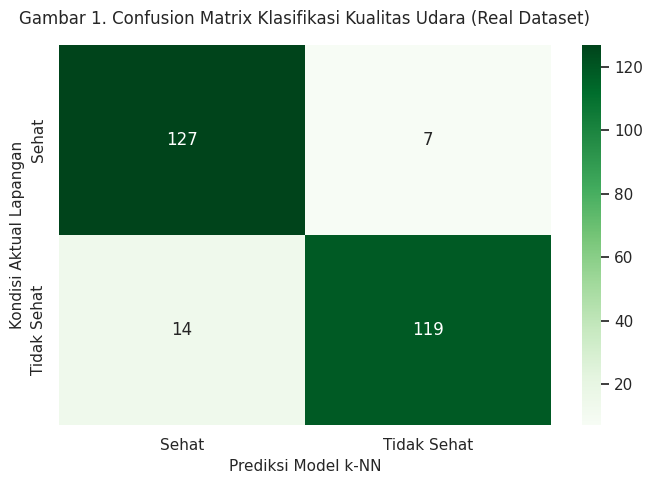

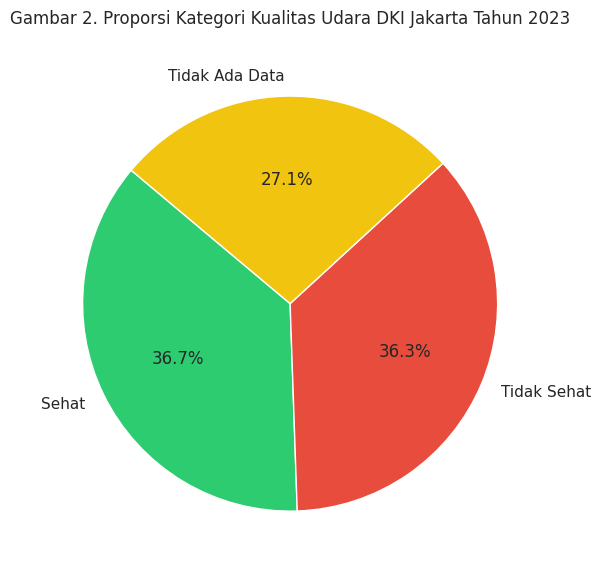


[SUKSES] File gambar 'confusion_matrix_real_ispu.png' dan 'proporsi_kategori_real_ispu.png' berhasil diekspor.


In [ ]:
print("\n" + "="*50)
print("      HASIL EVALUASI MODEL REAL DATASET (UNTUK PROPOSAL)")
print("="*50)

akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Akhir Model k-NN: {akurasi * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred, labels=['Sehat', 'Tidak Sehat'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sehat', 'Tidak Sehat'],
            yticklabels=['Sehat', 'Tidak Sehat'])
plt.title('Gambar 1. Confusion Matrix Klasifikasi Kualitas Udara (Real Dataset)', fontsize=12, pad=15)
plt.xlabel('Prediksi Model k-NN', fontsize=11)
plt.ylabel('Kondisi Aktual Lapangan', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_real_ispu.png', dpi=300)
plt.show()

# ── Pie chart: hanya 2 kategori (Sehat & Tidak Sehat) ────────────────────────
# df_clean sudah bersih, tidak ada kategori 'Tidak Ada Data'
plt.figure(figsize=(6, 6))
proporsi_total = df_clean['kategori_baru'].value_counts()
warna = ['#2ecc71' if label == 'Sehat' else '#e74c3c' for label in proporsi_total.index]
wedges, texts, autotexts = plt.pie(
    proporsi_total,
    labels=proporsi_total.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=warna,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
plt.title('Gambar 2. Proporsi Kategori Kualitas Udara DKI Jakarta Tahun 2023', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('proporsi_kategori_real_ispu.png', dpi=300)
plt.show()

print(f"\n[INFO] Distribusi final: {dict(proporsi_total)}")
print("\n[SUKSES] File gambar 'confusion_matrix_real_ispu.png' dan 'proporsi_kategori_real_ispu.png' berhasil diekspor.")


# HYPERPARAMETER TUNING (K OPTIMAL)

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold

print("[INFO] Mencari nilai k optimal dengan GridSearchCV + 5-Fold Cross-Validation...")

# Grid Search untuk mencari k terbaik
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

k_terbaik = grid_search.best_params_['n_neighbors']
akurasi_cv = grid_search.best_score_

print(f"\n--- Hasil Grid Search ---")
print(f"k terbaik    : {k_terbaik}")
print(f"Akurasi CV   : {akurasi_cv * 100:.2f}%")

# Tampilkan semua hasil k
print("\n--- Perbandingan Semua Nilai k ---")
cv_results = grid_search.cv_results_
for k, mean_score, std_score in zip(
    cv_results['param_n_neighbors'],
    cv_results['mean_test_score'],
    cv_results['std_test_score']
):
    print(f"  k={k:>2} | Akurasi CV: {mean_score*100:.2f}% (+/- {std_score*100:.2f}%)")

# Visualisasi: k vs akurasi CV
plt.figure(figsize=(8, 4))
k_values = [p['n_neighbors'] for p in grid_search.cv_results_['params']]
mean_scores = grid_search.cv_results_['mean_test_score']
plt.plot(k_values, mean_scores * 100, 'o-', color='#2980b9', linewidth=2, markersize=7)
plt.axvline(x=k_terbaik, color='#e74c3c', linestyle='--', label=f'k optimal = {k_terbaik}')
plt.title('Gambar 3. Akurasi Cross-Validation per Nilai k (k-NN)', fontsize=12, pad=15)
plt.xlabel('Nilai k (Jumlah Tetangga)', fontsize=11)
plt.ylabel('Akurasi CV (%)', fontsize=11)
plt.xticks(k_values)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('grafik_k_vs_akurasi.png', dpi=300)
plt.show()
print("[SUKSES] Grafik k vs akurasi disimpan sebagai 'grafik_k_vs_akurasi.png'")


# MODELING ULANG DENGAN K OPTIMAL

In [ ]:
print(f"[INFO] Melatih ulang model k-NN dengan k={k_terbaik} (k optimal)...")

knn_model = KNeighborsClassifier(n_neighbors=k_terbaik)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

akurasi_final = accuracy_score(y_test, y_pred)

print("\n" + "="*55)
print("   HASIL EVALUASI AKHIR MODEL k-NN (K OPTIMAL)")
print("="*55)
print(f"Nilai k yang digunakan : {k_terbaik}")
print(f"Akurasi Test Set       : {akurasi_final * 100:.2f}%")
print(f"Akurasi Cross-Validation: {akurasi_cv * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Update confusion matrix dengan k optimal
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred, labels=['Sehat', 'Tidak Sehat'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sehat', 'Tidak Sehat'],
            yticklabels=['Sehat', 'Tidak Sehat'])
plt.title(f'Gambar 4. Confusion Matrix k-NN (k={k_terbaik}, K Optimal)', fontsize=12, pad=15)
plt.xlabel('Prediksi Model k-NN', fontsize=11)
plt.ylabel('Kondisi Aktual Lapangan', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_optimal.png', dpi=300)
plt.show()
print("[SUKSES] Confusion matrix optimal disimpan sebagai 'confusion_matrix_optimal.png'")


# SIMPAN MODEL UNTUK STREAMLIT DEPLOY

In [ ]:
import pickle
import os

print("[INFO] Menyimpan model, scaler, dan metadata untuk deployment Streamlit...")

# Simpan model k-NN
with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn_model, f)
print(f"[OK] knn_model.pkl ({os.path.getsize('knn_model.pkl'):,} bytes)")

# Simpan StandardScaler (WAJIB: scaler harus fit dari training data)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"[OK] scaler.pkl ({os.path.getsize('scaler.pkl'):,} bytes)")

# Simpan metadata model (untuk ditampilkan di Streamlit)
metadata = {
    'k_terbaik'      : int(k_terbaik),
    'akurasi_test'   : float(round(akurasi_final, 4)),
    'akurasi_cv'     : float(round(akurasi_cv, 4)),
    'features'       : features_numerik,
    'label_classes'  : ['Sehat', 'Tidak Sehat'],
    'train_size'     : int(X_train.shape[0]),
    'test_size'      : int(X_test.shape[0]),
    'threshold_pm25' : 75,
    'dataset'        : 'ISPU DKI Jakarta 2023',
}
with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print(f"[OK] model_metadata.pkl ({os.path.getsize('model_metadata.pkl'):,} bytes)")

print("\n" + "="*50)
print("RINGKASAN METADATA MODEL")
print("="*50)
for key, val in metadata.items():
    print(f"  {key:<20}: {val}")

print("\n[SUKSES] Semua file model berhasil disimpan!")
print("File yang dibutuhkan untuk deploy Streamlit:")
print("  - knn_model.pkl")
print("  - scaler.pkl")
print("  - model_metadata.pkl")
print("  - app.py (dibuat terpisah)")
print("  - requirements.txt (dibuat terpisah)")


# GENERATE REQUIREMENTS.TXT & STRUKTUR DEPLOY

In [ ]:
# ── Generate requirements.txt ──────────────────────────────────────────────
requirements = """streamlit==1.35.0
scikit-learn==1.4.2
pandas==2.2.2
numpy==1.26.4
matplotlib==3.8.4
seaborn==0.13.2
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)
print("[OK] requirements.txt dibuat")

# ── Generate app.py (Streamlit) ────────────────────────────────────────────
app_code = '''
import streamlit as st
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Konfigurasi halaman ──────────────────────────────────────────────────────
st.set_page_config(
    page_title="Klasifikasi Kualitas Udara DKI Jakarta",
    page_icon="🌫️",
    layout="wide"
)

# ── Load model & scaler ──────────────────────────────────────────────────────
@st.cache_resource
def load_artifacts():
    with open("knn_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    with open("model_metadata.pkl", "rb") as f:
        meta = pickle.load(f)
    return model, scaler, meta

model, scaler, meta = load_artifacts()

# ── Header ───────────────────────────────────────────────────────────────────
st.title("🌫️ Klasifikasi Kualitas Udara DKI Jakarta")
st.markdown("Berbasis **Algoritma K-Nearest Neighbors (k-NN)** · Data ISPU 2023")
st.divider()

# ── Sidebar: info model ───────────────────────────────────────────────────────
with st.sidebar:
    st.header("ℹ️ Informasi Model")
    st.metric("Algoritma", "K-Nearest Neighbors")
    st.metric("Nilai k Optimal", meta["k_terbaik"])
    st.metric("Akurasi Test Set", f"{meta[\"akurasi_test\"]*100:.2f}%")
    st.metric("Akurasi Cross-Validation (5-Fold)", f"{meta[\"akurasi_cv\"]*100:.2f}%")
    st.caption(f"Dataset: {meta[\"dataset\"]}")
    st.caption(f"Training: {meta[\"train_size\"]} baris | Test: {meta[\"test_size\"]} baris")

# ── Layout utama: 2 kolom ─────────────────────────────────────────────────────
col_input, col_result = st.columns([1, 1], gap="large")

with col_input:
    st.subheader("📋 Input Komponen ISPU")
    st.caption("Geser slider sesuai nilai pengukuran dari stasiun ISPU.")

    pm10 = st.slider("PM10 (μg/m³)",      min_value=0,   max_value=200, value=56,  step=1)
    pm25 = st.slider("PM2.5 (μg/m³)",     min_value=0,   max_value=300, value=75,  step=1)
    so2  = st.slider("SO₂ – Sulfur Dioksida (μg/m³)",    min_value=0, max_value=100, value=45, step=1)
    co   = st.slider("CO – Karbon Monoksida (μg/m³)",    min_value=0, max_value=60,  value=10, step=1)
    o3   = st.slider("O₃ – Ozon (μg/m³)",                min_value=0, max_value=100, value=26, step=1)
    no2  = st.slider("NO₂ – Nitrogen Dioksida (μg/m³)",  min_value=0, max_value=60,  value=18, step=1)

    prediksi_btn = st.button("🔍 Prediksi Kualitas Udara", type="primary", use_container_width=True)

with col_result:
    st.subheader("📊 Hasil Klasifikasi")

    if prediksi_btn:
        input_arr = np.array([[pm10, pm25, so2, co, o3, no2]])
        input_scaled = scaler.transform(input_arr)
        prediksi = model.predict(input_scaled)[0]
        proba    = model.predict_proba(input_scaled)[0]
        kelas    = meta["label_classes"]

        if prediksi == "Sehat":
            st.success(f"### ✅ Kualitas Udara: SEHAT")
            st.markdown("Kondisi udara dalam batas aman untuk aktivitas luar ruangan.")
        else:
            st.error(f"### ⚠️ Kualitas Udara: TIDAK SEHAT")
            st.markdown("Disarankan untuk mengurangi aktivitas luar ruangan dan menggunakan masker.")

        st.divider()
        st.caption("Probabilitas Prediksi:")
        for label, prob in zip(kelas, proba):
            st.progress(float(prob), text=f"{label}: {prob*100:.1f}%")

        # Tabel input
        st.divider()
        st.caption("Nilai input yang digunakan:")
        df_input = pd.DataFrame({
            "Komponen"     : ["PM10", "PM2.5", "SO₂", "CO", "O₃", "NO₂"],
            "Nilai (μg/m³)": [pm10, pm25, so2, co, o3, no2]
        })
        st.dataframe(df_input, use_container_width=True, hide_index=True)
    else:
        st.info("Atur nilai komponen ISPU di sebelah kiri, lalu klik tombol **Prediksi**.")
'''

with open('app.py', 'w') as f:
    f.write(app_code.lstrip())
print("[OK] app.py dibuat")

print("\n" + "="*55)
print("STRUKTUR FILE YANG DIPERLUKAN UNTUK DEPLOY")
print("="*55)
print("""
📁 folder-project/
├── app.py                  ← Aplikasi Streamlit (sudah dibuat)
├── requirements.txt        ← Dependensi Python (sudah dibuat)
├── knn_model.pkl           ← Model k-NN terlatih (sudah disimpan)
├── scaler.pkl              ← StandardScaler (sudah disimpan)
├── model_metadata.pkl      ← Metadata model (sudah disimpan)
└── data-ispu-2023.csv      ← Dataset (opsional, untuk referensi)

Cara deploy ke Streamlit Community Cloud:
  1. Upload semua file ke GitHub repository
  2. Buka https://share.streamlit.io
  3. Pilih repository → Branch → app.py
  4. Klik Deploy!
""")
